In [51]:
import numpy as np
import pandas as pd
import math
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.cluster import DBSCAN
from sklearn.ensemble import HistGradientBoostingRegressor
from fancyimpute import SoftImpute
from sklearn.preprocessing import OneHotEncoder
from sklearn.multioutput import MultiOutputRegressor
import os
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn import tree

# Load Data

In [2]:
raw_data  = pd.read_csv("./Dataset/BOM.csv")

In [3]:
raw_data.head(-50)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145405,2017-05-02,Uluru,9.1,23.8,0.0,NaN,NaN,SSE,35.0,SSE,...,66.0,36.0,1023.2,1020.4,NaN,4.0,15.8,22.4,No,No
145406,2017-05-03,Uluru,9.2,22.3,0.0,NaN,NaN,E,44.0,E,...,55.0,33.0,1026.2,1022.3,NaN,NaN,14.3,21.2,No,No
145407,2017-05-04,Uluru,8.8,22.9,0.0,NaN,NaN,E,35.0,E,...,50.0,28.0,1025.8,1021.9,NaN,NaN,13.8,22.2,No,No
145408,2017-05-05,Uluru,5.7,26.0,0.0,NaN,NaN,ENE,26.0,E,...,41.0,20.0,1024.9,1020.8,NaN,NaN,13.8,24.8,No,No


# Data Understanding

## Data Shape

In [4]:
print("Data Shape is :")
raw_data.shape

Data Shape is :


(145460, 23)

## Data Info

In [5]:
print("Data info is :")
missing_percent = (raw_data.isnull().sum() / len(raw_data)) * 100
print(missing_percent)

Data info is :
Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64


##  Column Type

In [6]:
print("Data column type is :")
raw_data.dtypes.value_counts()

Data column type is :


float64    16
object      7
Name: count, dtype: int64

## Split Columns

In [7]:
numric_columns = raw_data.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = raw_data.select_dtypes(include=['object']).columns

## NAN Data

In [8]:
raw_data.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [9]:
missing_percent = (raw_data.isnull().sum() / len(raw_data)) * 100
missing_percent

Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64

<Axes: >

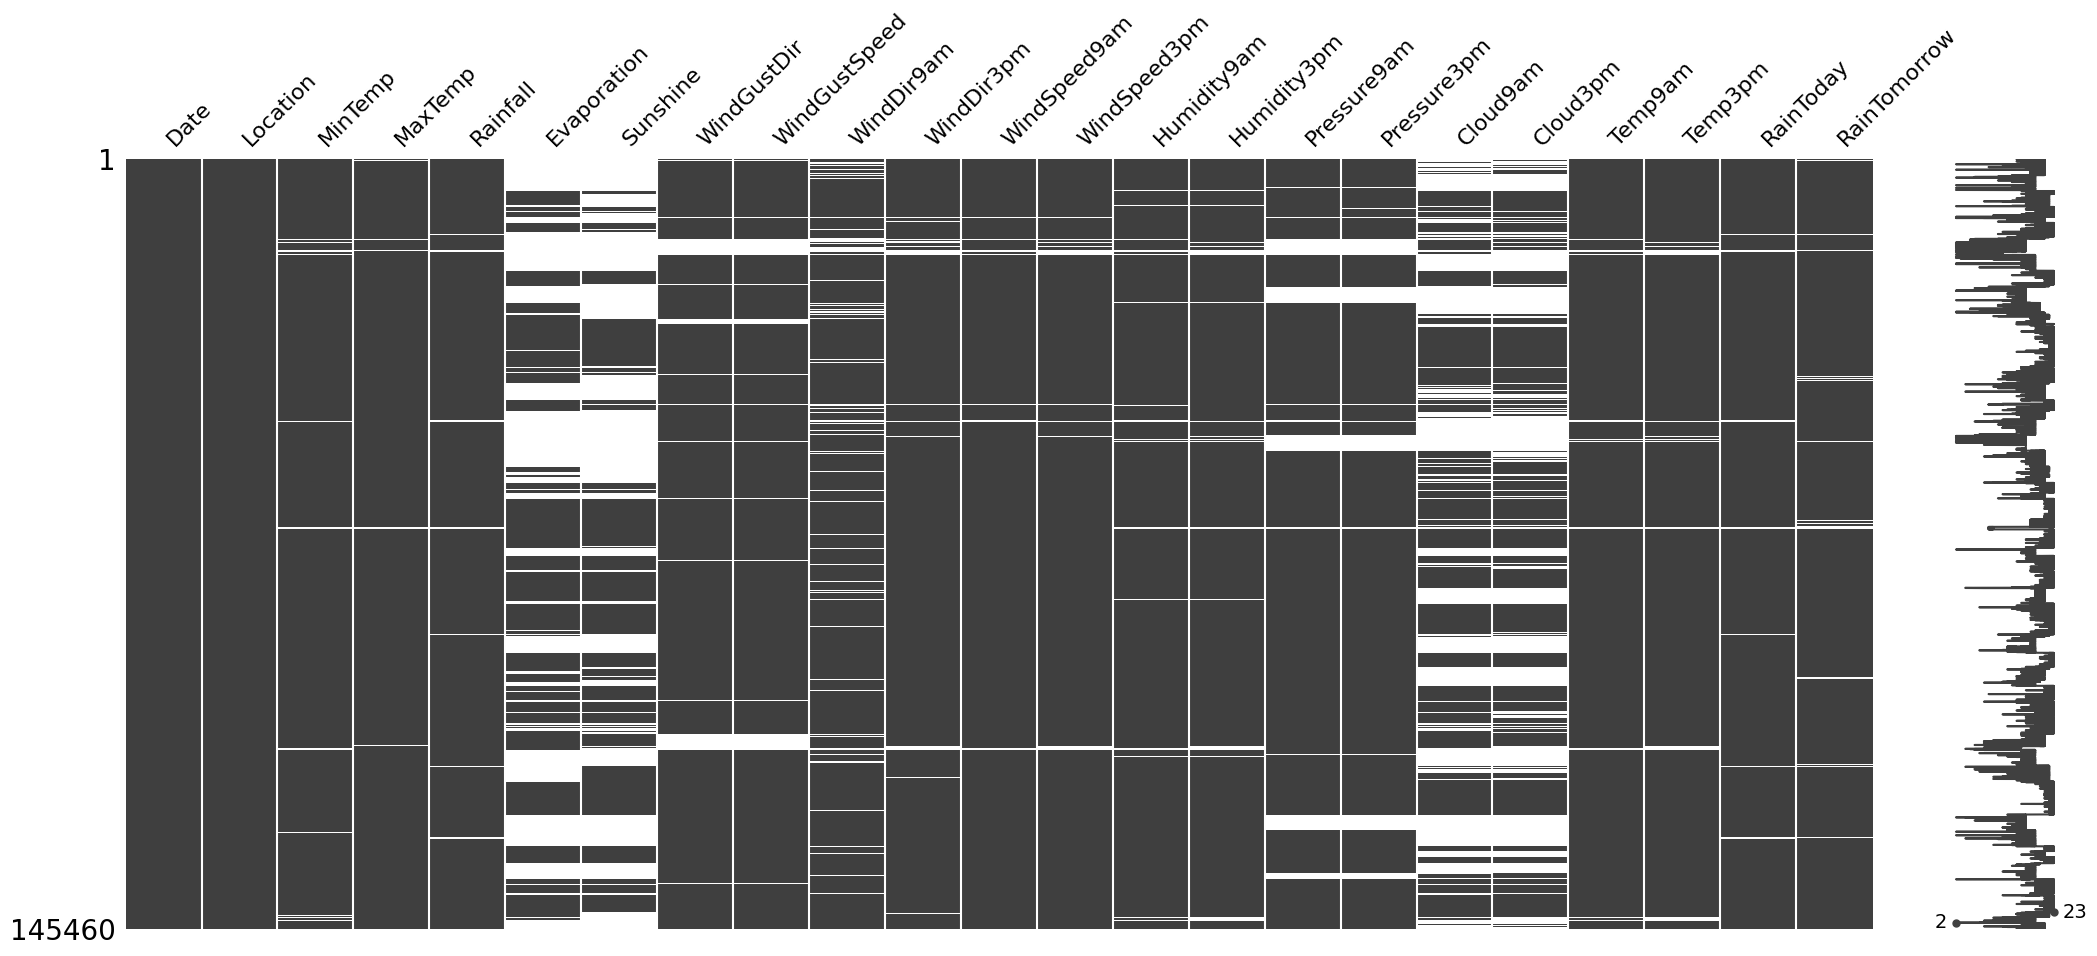

In [10]:
msno.matrix(raw_data) 

## Duplicate Data

In [11]:
raw_data.duplicated().sum()

np.int64(0)

## Correlation 

In [12]:
numric_columns_correlation = raw_data[numric_columns]
numric_columns_correlation

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.4,0.0,NaN,NaN,31.0,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4
145456,3.6,25.3,0.0,NaN,NaN,22.0,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5
145457,5.4,26.9,0.0,NaN,NaN,37.0,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1
145458,7.8,27.0,0.0,NaN,NaN,28.0,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0


In [13]:
correlation_matrix = numric_columns_correlation.corr(method='pearson')

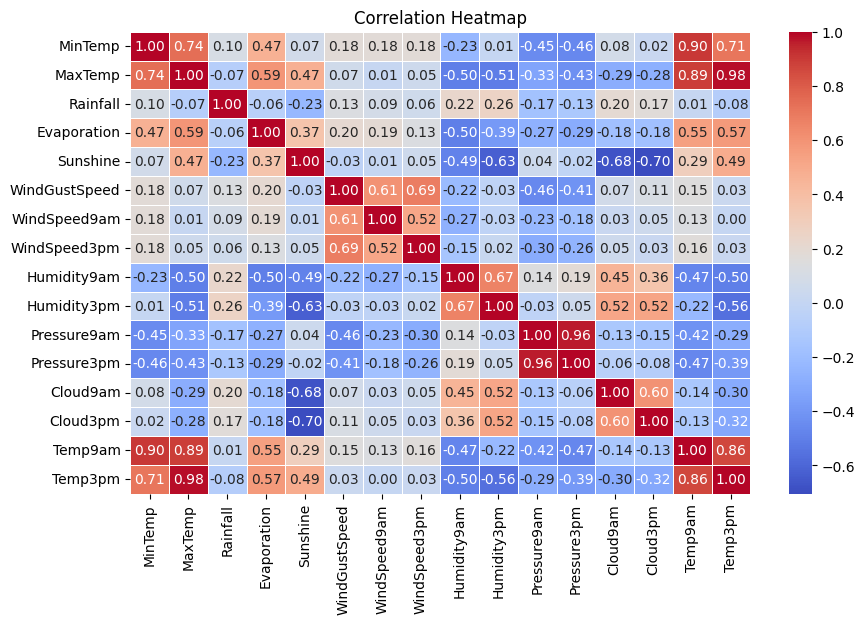

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Normal Data

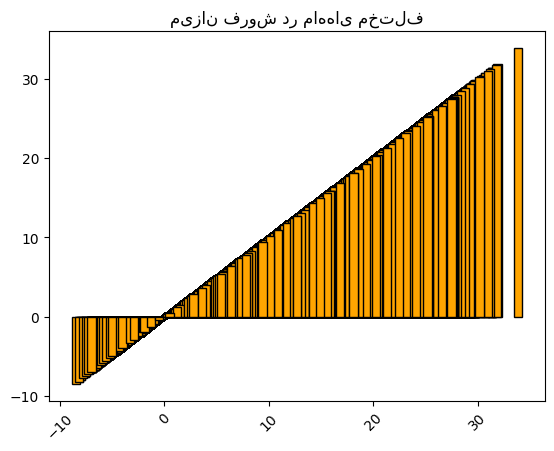

In [17]:
plt.bar(raw_data["MinTemp"],height=raw_data["MinTemp"], color='orange', edgecolor='black')
plt.title("میزان فروش در ماه‌های مختلف")
plt.xticks(rotation=45)  # چرخش لیبل‌های محور X
plt.show()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

NameError: name 'x' is not defined

# Data Cleaning

In [16]:
x = raw_data.iloc[:,0:22]
y = raw_data.iloc[:,22:23]

### Missing Value

In [17]:
SoftImputeModel = SoftImpute()
x_numric_null_clean = SoftImputeModel.fit_transform(x[numric_columns])
x_numric_null_clean = pd.DataFrame(data=x_numric_null_clean,columns=numric_columns)
x_numric_null_clean.isna().sum()

C:\Users\hosein\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hosein\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hosein\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 520229.809737
[SoftImpute] Iter 1: observed MAE=9.405592 rank=3
[SoftImpute] Iter 2: observed MAE=9.351922 rank=3
[SoftImpute] Iter 3: observed MAE=9.300407 rank=2
[SoftImpute] Iter 4: observed MAE=9.275108 rank=2
[SoftImpute] Iter 5: observed MAE=9.263172 rank=2
[SoftImpute] Iter 6: observed MAE=9.257268 rank=2
[SoftImpute] Iter 7: observed MAE=9.254188 rank=2
[SoftImpute] Iter 8: observed MAE=9.252461 rank=2
[SoftImpute] Iter 9: observed MAE=9.251388 rank=2
[SoftImpute] Iter 10: observed MAE=9.250634 rank=2
[SoftImpute] Iter 11: observed MAE=9.250038 rank=2
[SoftImpute] Iter 12: observed MAE=9.249520 rank=2
[SoftImpute] Iter 13: observed MAE=9.249042 rank=2
[SoftImpute] Iter 14: observed MAE=9.248585 rank=2
[SoftImpute] Iter 15: observed MAE=9.248141 rank=2
[SoftImpute] Iter 16: observed MAE=9.247706 rank=2
[SoftImpute] Iter 17: observed MAE=9.247277 rank=2
[SoftImpute] Iter 18: observed MAE=9.246853 rank=2
[SoftImpute] Iter 19: observed MA

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

In [18]:
x_categorical_data = x[categorical_columns[0:6]]  
y_categorical_data = y[categorical_columns[6:7]]  

In [19]:
x_categorical_data

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
0,2008-12-01,Albury,W,W,WNW,No
1,2008-12-02,Albury,WNW,NNW,WSW,No
2,2008-12-03,Albury,WSW,W,WSW,No
3,2008-12-04,Albury,NE,SE,E,No
4,2008-12-05,Albury,W,ENE,NW,No
...,...,...,...,...,...,...
145455,2017-06-21,Uluru,E,SE,ENE,No
145456,2017-06-22,Uluru,NNW,SE,N,No
145457,2017-06-23,Uluru,N,SE,WNW,No
145458,2017-06-24,Uluru,SE,SSE,N,No


In [20]:
for col in x_categorical_data:
    x_categorical_data.loc[:, col] = x_categorical_data[col].fillna(x_categorical_data[col].mode()[0])

In [21]:
for col in y_categorical_data:
    y_categorical_data.loc[:, col] = y_categorical_data[col].fillna(y_categorical_data[col].mode()[0])

In [22]:
data = np.hstack((x_numric_null_clean, x_categorical_data))  
data = np.hstack((data, y_categorical_data))  
data_null_clean = pd.DataFrame(data=data)

In [23]:
x_null_clean = data_null_clean.iloc[:,0:22]
y_null_clean = data_null_clean.iloc[:,22:23]

### برای تشخیص و حذف اوتلایر
### 1 - روش IQR (Interquartile Range) - بهترین برای داده‌های توزیع نرمال
### 2 - روش Z-Score - مناسب برای داده‌های توزیع نرمال
### 3 - روش DBSCAN - مناسب برای داده‌های پیچیده و غیرخطی
### 4 - روش Isolation Forest - مناسب برای مجموعه داده‌های بزرگ

### برای تشخیص اینکه داده‌ها خطی (Linear) هستند یا غیرخطی (Non-Linear)
### 1 - روش تصویری: رسم نمودار Scatter Plot
### 2 - روش آماری: محاسبه ضریب همبستگی (Correlation Coefficient)

In [25]:
X_train_null_clean, X_test_null_clean, y_train_null_clean, y_test_null_clean = train_test_split(x_null_clean, y_null_clean, test_size=0.2, random_state=42)

In [26]:
x_null_clean.iloc[:,17:22]

,17,18,19,20,21
0,Albury,W,W,WNW,No
1,Albury,WNW,NNW,WSW,No
2,Albury,WSW,W,WSW,No
3,Albury,NE,SE,E,No
4,Albury,W,ENE,NW,No
...,...,...,...,...,...
145455,Uluru,E,SE,ENE,No
145456,Uluru,NNW,SE,N,No
145457,Uluru,N,SE,WNW,No
145458,Uluru,SE,SSE,N,No


In [27]:
XEncoder = OneHotEncoder(drop='first', sparse_output=False)
YEncoder = OneHotEncoder(drop='first', sparse_output=False)
x_null_clean_encode = XEncoder.fit_transform(x_null_clean.iloc[:,17:22])
y_null_clean_encode = YEncoder.fit_transform(y_null_clean)

In [29]:
x_null_clean_encode = pd.DataFrame(x_null_clean_encode)
x_null_clean_encode.columns = [f"enc_{i}" for i in range(x_null_clean_encode.shape[1])]
x_encode_null_clean = pd.concat([x_null_clean_encode, x_null_clean.iloc[:, 0:17]], axis=1)
x_encode_null_clean.columns = range(1, len(x_encode_null_clean.columns) + 1)


In [30]:
y_null_clean_encode = pd.DataFrame(y_null_clean_encode)
y_null_clean_encode

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145455,0.0
145456,0.0
145457,0.0
145458,0.0


In [31]:
os.environ["LOKY_MAX_CPU_COUNT"] = "6" 
MultiOutputRegressorModel = MultiOutputRegressor(HistGradientBoostingRegressor())
MultiOutputRegressorModel.fit(x_encode_null_clean.iloc[:,0:110],y_null_clean_encode)
dbscan = DBSCAN(eps=0.5, min_samples=5)
outliers = dbscan.fit_predict(x_encode_null_clean.iloc[:,0:110])
outliers

array([-1, -1, -1, ..., -1, -1, -1], shape=(145460,))

In [32]:
x_null_outlier_clean = x_encode_null_clean[outliers==-1]
y_null_outlier_clean = y_null_clean_encode[outliers==-1]

# Standard Scaler

In [33]:
scaler = StandardScaler()
x_null_outlier_clean_scalle = scaler.fit_transform(x_null_outlier_clean.iloc[:,0:110])
x_null_outlier_clean_scalle = pd.DataFrame(x_null_outlier_clean_scalle)

# Train Test Split And Shuffle

In [34]:
x , y = shuffle(x_null_outlier_clean_scalle, y_null_outlier_clean, random_state=42)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    x.iloc[:,0:110], y, test_size=0.2, random_state=42)

# KNN

In [42]:
y_train = np.ravel(y_train)

In [43]:
KNeighborsClassifierModel = KNeighborsClassifier(n_neighbors=5)
KNeighborsClassifierModel.fit(x_train, y_train)
score = KNeighborsClassifierModel.score(x_test,y_test)
score

0.8036366140918796

In [45]:
pred = KNeighborsClassifierModel.predict(x_test)

In [46]:
cm = confusion_matrix(y_test, pred)

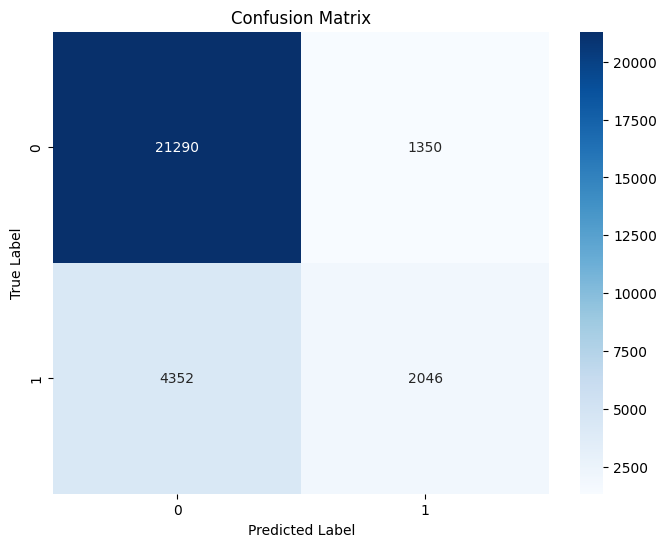

In [47]:
# رسم نمودار
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=True, yticklabels=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [74]:
for i in range(3,20):
    KNeighborsClassifierModel = KNeighborsClassifier(n_neighbors=i)
    KNeighborsClassifierModel.fit(x_train, y_train)
    score = KNeighborsClassifierModel.score(x_test,y_test)
    print(score)
    print(i)
    

0.7932708864246849
3
0.8024657345547214
4
0.8036366140918796
5
0.8060128107996418
6
0.8074247537709208
7
0.8065638129347751
8
0.8087333838418624
9
0.806598250568221
10
0.8094565741442248
11
0.8083545698739583
12
0.8100764515462497
13
0.8069426269026793
14
0.8098698257455748
15
0.8071492527033542
16
0.8101108891796955
17
0.806977064536125
18
0.8093532612438873
19


# Decision Tree

In [73]:
DecisionTreeModel = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=12,
                                                min_samples_split=3, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                                max_features=None, random_state=None, max_leaf_nodes=None,
                                                min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
DecisionTreeModel = DecisionTreeModel.fit(x_train, y_train)
DecisionTreeScore = DecisionTreeModel.score(x_test, y_test)
DecisionTreeScore

0.8339417315242097